# Diffusion  Models

We are going to implement in torch Diffusion models from the original paper about DDPMs: <i>Denoising Diffusion Probabilistic Models</i> (https://arxiv.org/pdf/2006.11239.pdf) by Ho et. al.

https://hojonathanho.github.io/diffusion/


A diffusion probabilistic model is a type of generative model that learns to construct data by gradually transforming random noise into structured patterns. The training process works as follows:

1.   (forward) given a sample, add noise using a deterministic procedure.
2.   (backward) learn to undo the addition of the noise.

After training we can sample from the decoder process by starting with random noise and denoising until obtaining a sample.


# Installs

The only package we will need is the **einops** package. This will be used to create a nice GIF animation of our DDPM model.

In [153]:
'''!pip3 install --upgrade pip
!pip3 install einops'''

'!pip3 install --upgrade pip\n!pip3 install einops'

In [154]:
# Imports
import torch
import numpy as np
from torch import nn
from tqdm import tqdm
import torch.utils.data
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll

import random
import imageio
import numpy as np
from argparse import ArgumentParser

from tqdm.auto import tqdm
import matplotlib.pyplot as plt

import einops
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader

from torchvision.transforms import Compose, ToTensor, Lambda
from torchvision.datasets.mnist import MNIST, FashionMNIST

Select the device type depending on the system. You are advised on using google colab with gpu support for the following exercises.

In [155]:
# Windows, Ubuntu with gpu
#device = 'cuda'

# M1 M2 macOS
#device = 'mps'

#others (if really slow, consider using google colab!)
device = 'cpu'


## 10.1 Diffusion Model

Let us start with a simple example based on an MLP. The idea is to use a diffusion model to create 2D noise data and then learn to denoise the distribution back to the original set of points (swiss_roll). Let us start to create an MLP with N layers. All sequential with linear layers followed by Relu activations.

In [156]:
class MLP(nn.Module):
    def __init__(self, N=40, data_dim=2, hidden_dim=64):
        super(MLP, self).__init__()
        self.network_head = nn.Sequential(nn.Linear(data_dim, hidden_dim), nn.ReLU(),
                                          nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), )
        self.network_tail = nn.ModuleList([nn.Sequential(nn.Linear(hidden_dim, hidden_dim),
                                                         nn.ReLU(), nn.Linear(hidden_dim, data_dim * 2)
                                                         ) for _ in range(N)])
        # tail vai aprender a prever o ruído
        # vamos ter uma rede para cada passo de tempo
        
    def forward(self, x, t: int):
        h = self.network_head(x)
        return self.network_tail[t](h)

We now breakdown the diffusion model based on the above overview of the algorithm. More details can be found in the paper : 
https://arxiv.org/abs/1503.03585

Overall, this segment of code is setting up the key parameters that control how data is converted into noise during the diffusion process and how it is reconstructed during the reverse process. These parameters include:

- **Beta values (𝛽)**: Control the amount of noise added at each step.
- **Alpha values (𝛼)**: Indicate the remaining proportion of original data after noise addition at each step.
- **Cumulative alpha values (𝛼̅)**: Track the total proportion of original data retained across multiple steps.
- **Variance of noise (𝜎²)**: Directly linked to beta, indicating the noise variance at each step.

This configuration is essential for ensuring the model performs both the noise addition and the noise removal (sampling) processes effectively, maintaining the balance necessary for generating high-quality outputs from the model.


In [157]:
class DiffusionModel(nn.Module):

    def __init__(self, model: nn.Module, n_steps=40, device='cuda'):
        super().__init__()

        self.model = model
        self.device = device

        # based on the paper, is an acceptable value for beta to ensure stability on the process
        upper_bound_beta = 0.3 
        # ensures that is a small value but not 0
        residual = 1e-5 
        
        # some papers argue that it can be linearly spaced! try it out later :)
        betas = torch.linspace(-18, 10, n_steps) 
        self.beta = torch.sigmoid(betas) * (upper_bound_beta - residual) + residual

        # alpha values - quantidade de informação que permanece após a adição de ruído na imagem
        self.alpha = 1. - self.beta
        #  total proportion of the original data that remains after successive applications of noise up to each timestep
        self.alpha_bar = torch.cumprod(self.alpha, dim=0)
        
        self.n_steps = n_steps
        # same value of beta!
        self.sigma2 = self.beta

    
    # generate data!
    def sample(self, size, device):
        noise = torch.randn((size, 2)).to(device)
        samples = [noise]
        for t in range(self.n_steps):
            _, _, x = self.reverse(samples[-1], self.n_steps - t - 1 + 1)
            samples.append(x)
        return samples
    
    
    # forward diffusion process - add noise to the data
    def forward_process(self, x0, t):

                t = t - 1  # Start indexing at 0
                
                # Params at step t
                beta_forward = self.beta[t]
                alpha_forward = self.alpha[t]
                alpha_cum_forward = self.alpha_bar[t]
                
                # calculate noisy data at step t. faz uma média pesada entre a imagem original e o ruído
                xt = x0 * torch.sqrt(alpha_cum_forward) + torch.randn_like(x0) * torch.sqrt(1. - alpha_cum_forward)
                
                # calculation of mean and variance do ruído naquele momento
                mu1_scl = torch.sqrt(alpha_cum_forward / alpha_forward)
                mu2_scl = 1. / torch.sqrt(alpha_forward)
                cov1 = 1. - alpha_cum_forward / alpha_forward
                cov2 = beta_forward / alpha_forward
                lam = 1. / cov1 + 1. / cov2
                mu = (x0 * mu1_scl / cov1 + xt * mu2_scl / cov2) / lam
                sigma = torch.sqrt(1. / lam)
                
                return mu, sigma, xt
    
    # reverse diffusion process - remove noise from the data
    def reverse(self, xt, t):

        t = t - 1  # Start indexing at 0
        if t == 0: return None, None, xt
        # Next line invokes the model with the current state of the data xt and the timestep t. 
        # mu represents the predicted mean 
        # h represents log variance 
        mu, h = self.model(xt, t).chunk(2, dim=1)
        # get standard deviation based on log variance
        sigma = torch.sqrt(torch.exp(h))
        # New samples are generated by adding Gaussian noise scaled by `sigma` to the mean `mu`.
        samples = mu + torch.randn_like(xt) * sigma
        
        return mu, sigma, samples

The forward process of the diffusion model. It computes the necessary parameters to transition from the original data $x_0$ to a noised version $x_t$ at a specific timestep $t$, based on the model's defined dynamics (via alpha and beta values). The output parameters $\mu$ and $\sigma$ are typically used to sample the next state of the process, ensuring the correct probabilistic transformation according to the defined noise model. This step-by-step noise addition mimics the real-world process of data degradation and is foundational for learning to reverse this process to generate new data samples.


In [158]:
# def forward_process(self, x0, t)

This function is a core part of the reverse process in a diffusion model, where it iteratively reconstructs the original data by reversing the diffusion steps. Each call to `reverse` aims to estimate and refine the data's previous state, gradually denoising it until potentially reaching the original data distribution. This iterative refinement is central to generating high-quality samples from the model.

In [159]:
# def reverse(self, xt, t)

In [160]:
# simple data from the swiss_roll. Try other 2d distributions !
def sample_batch(size):
    x, _ = make_swiss_roll(size)
    return x[:, [2, 0]] / 10.0 * np.array([1, -1])

Implement the missing training steps: 1.,2.,3. (check comments). The idea is to call the above explained methods to first, do the forwarding process (1.) and reverse it (2.), perform and optimisation step and use backpropation based on the loss (3.)

In [161]:
# injetamos ruídos em todas as direções

def train(model, optimizer, nb_epochs=150_000, batch_size=64_000):
    training_loss = []
    for _ in tqdm(range(nb_epochs)):
        x0 = torch.from_numpy(sample_batch(batch_size)).float().to(device)
        t = np.random.randint(2, 40 + 1)

        #1. add noise using model.forward_process(...)
        mu, sigma, xt = model.forward_process(x0, t)
        # mu - mean of the noise
        # sigma - standard deviation of the noise
        # xt - noisy data
        
        #2. reverse the noise using model.reverse(....)
        mu_posterior, sigma_posterior, xt_posterior = model.reverse(xt, t)
        # mu_posterior - mean of the noise predicted by the model
        # sigma_posterior - standard deviation of the noise predicted by the model
        # xt_posterior - noisy data predicted by the model
        
        # compute KL - distância entre a distribuição de ruído e a distribuição de ruído prevista pela rede neural
        KL = (torch.log(sigma) - torch.log(sigma_posterior) + (sigma_posterior ** 2 + (mu_posterior - mu) ** 2) / (
                2 * sigma ** 2) - 0.5)
        # compute loss
        loss = KL.mean()

        #3. backprop and optimizer step
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        training_loss.append(loss.item())

Code to check the original data and generated data of the difussion model

In [162]:
# check the 2 distributions
def plot(model):
    plt.figure(figsize=(10, 6))
    x0 = sample_batch(5000)
    x20 = forward_process(model, torch.from_numpy(x0).to(device), 20)[-1].data.cpu().numpy()
    x40 = forward_process(model, torch.from_numpy(x0).to(device), 40)[-1].data.cpu().numpy()
    data = [x0, x20, x40]
    for i, t in enumerate([0, 20, 39]):
        plt.subplot(2, 3, 1 + i)
        plt.scatter(data[i][:, 0], data[i][:, 1], alpha=.1, s=1)
        plt.xlim([-2, 2])
        plt.ylim([-2, 2])
        plt.gca().set_aspect('equal')
        if t == 0: plt.ylabel(r'$q(\mathbf{x}^{(0...T)})$', fontsize=17, rotation=0, labelpad=60)
        if i == 0: plt.title(r'$t=0$', fontsize=17)
        if i == 1: plt.title(r'$t=\frac{T}{2}$', fontsize=17)
        if i == 2: plt.title(r'$t=T$', fontsize=17)

    samples = model.sample(5000, device)
    for i, t in enumerate([0, 20, 40]):
        plt.subplot(2, 3, 4 + i)
        plt.scatter(samples[40 - t][:, 0].data.cpu().numpy(), samples[40 - t][:, 1].data.cpu().numpy(),
                    alpha=.1, s=1, c='r')
        plt.xlim([-2, 2])
        plt.ylim([-2, 2])
        plt.gca().set_aspect('equal')
        if t == 0: plt.ylabel(r'$p(\mathbf{x}^{(0...T)})$', fontsize=17, rotation=0, labelpad=60)
    plt.savefig(f"data_diffusion_model.png", bbox_inches='tight')
    #plt.close()

Entry point to the definition of the models and training.
Train for different number of epochs: 1000, 10000, 200000 - what can you observe? Altough with MLP the process is hard, it slowly converges. (This may take a while to train)

100%|██████████| 1000/1000 [00:02<00:00, 496.08it/s]


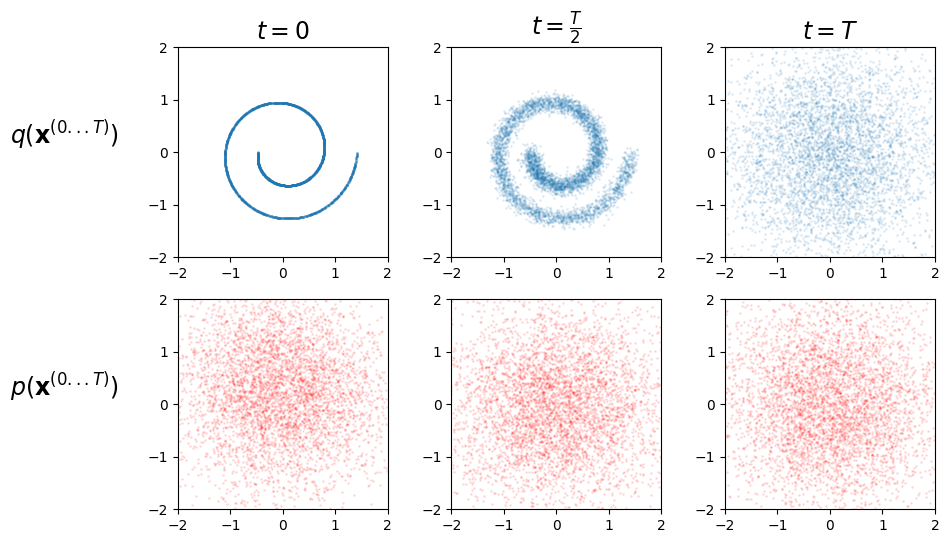

In [163]:

# create MLP.
model_mlp = MLP().to(device)
model = DiffusionModel(model_mlp)
optimizer = torch.optim.Adam(model_mlp.parameters(), lr=1e-4)
train(model, optimizer, nb_epochs=1000, batch_size=500)
plot(model)

## 10.2 Denoising Diffusion Probabilistic Models

Let us use a better architecture and more complex datasets. This section is based on the work down on the paper: https://arxiv.org/abs/2006.11239 . It is also an adaptation of starting examples for denoising diffusion probabilistic models from https://huggingface.co/docs/diffusers/en/index. The folowing example works with MNIST and FashionMNIST and can be adapted to other datasets.

In [164]:
# Setting reproducibility
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Definitions
STORE_PATH_MNIST = f"ddpm_model_mnist.pt"
STORE_PATH_FASHION = f"ddpm_model_fashion.pt"

## Execution options

Here's a few options you should set:

 - `no_train` specifies whether you want to skip the training loop and just use a pre-trained model. If you haven't trained a model already using this notebook, keep this as `False`. If you want to use a pre-trained model, load it in the colab filesystem.

- `fashion` specifies whether you want to use the Fashion-MNIST dataset (`True`) or not and use the MNIST dataset instead (`False`).

- `batch_size`, `n_epochs` and `lr` are your typical training hyper-parameters. Notice that `lr=0.001` is the hyper-parameter used by the authors.


In [165]:
no_train = False
fashion = False
batch_size = 128
n_epochs = 10
lr = 0.001

In [166]:
store_path = "ddpm_fashion.pt" if fashion else "ddpm_mnist.pt"

# Utility functions

Following are two utility functions: `show_images` allows to display images in a square-like pattern with a custom title, while `show_fist_batch` simply shows the images in the first batch of a DataLoader object.

In [167]:
def show_images(images, title=""):
    """Shows the provided images as sub-pictures in a square"""

    # Converting images to CPU numpy arrays
    if type(images) is torch.Tensor:
        images = images.detach().cpu().numpy()

    # Defining number of rows and columns
    fig = plt.figure(figsize=(8, 8))
    rows = int(len(images) ** (1 / 2))
    cols = round(len(images) / rows)

    # Populating figure with sub-plots
    idx = 0
    for r in range(rows):
        for c in range(cols):
            fig.add_subplot(rows, cols, idx + 1)

            if idx < len(images):
                plt.imshow(images[idx][0], cmap="gray")
                idx += 1
    fig.suptitle(title, fontsize=30)

    # Showing the figure
    plt.show()

In [168]:
def show_first_batch(loader):
    for batch in loader:
        show_images(batch[0], "Images in the first batch")
        break

## Loading data
We will use the MNIST (or FashionMNIST) dataset and try to generate some new samples out of (nowhere, but starting from some) random gaussian noise. **NOTE**: It is important to normalize images in range `[-1,1]` and not `[0,1]` as one might usually do. This is because the DDPM network predicts normally distributed noises throughout the denoising process.

In [169]:
# Loading the data (converting each image into a tensor and normalizing between [-1, 1])
transform = Compose([
    ToTensor(),
    Lambda(lambda x: (x - 0.5) * 2)]
)
ds_fn = FashionMNIST if fashion else MNIST
dataset = ds_fn("./datasets", download=True, train=True, transform=transform)
loader = DataLoader(dataset, batch_size, shuffle=True)

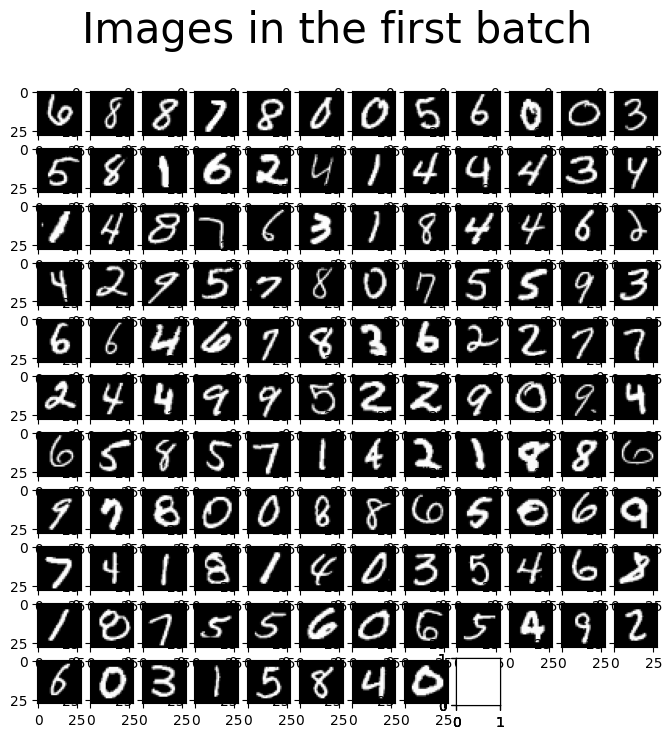

In [170]:
# Optionally, show a batch of regular images
show_first_batch(loader)

# Defining the DDPM module

We now proceed and define a DDPM PyTorch module. Since in principle the DDPM scheme is independent of the model architecture used in each denoising step, we define a high-level model that is constructed using a `network` parameter, as well as:

- `n_steps`: number of diffusion steps $T$;
- `min_beta`: value of the first $\beta_t$ ($\beta_1$);
- `max_beta`: value of the last  $\beta_t$ ($\beta_T$);
- `device`: device onto which the model is run;
- `image_chw`: tuple containing the dimensionality of the input images.

The `forward` process of DDPMs benefits from a nice property: We don't actually need to slowly add noise step-by-step, but we can directly skip to whathever step $t$ we want using coefficients $\alpha_bar$.

For the `backward` method instead, we simply let the network do the job.

Note that in this implementation, $t$ is assumed to be a `(N, 1)` tensor, where `N` is the number of images in tensor `x`. We thus support different time-steps for multiple images.

In [171]:
# DDPM class
class MyDDPM(nn.Module):
    def __init__(self, network, n_steps=200, min_beta=10 ** -4, max_beta=0.02, device=None, image_chw=(1, 28, 28)):
        super(MyDDPM, self).__init__()
        self.n_steps = n_steps  # como são imagens temos de usar um número maior de passos
        self.device = device
        self.image_chw = image_chw
        self.network = network.to(device)
        self.betas = torch.linspace(min_beta, max_beta, n_steps).to(
            device)  # Number of steps is typically in the order of thousands
        self.alphas = 1 - self.betas
        self.alpha_bars = torch.tensor([torch.prod(self.alphas[:i + 1]) for i in range(len(self.alphas))]).to(device)

    def forward(self, x0, t, eta=None):
        # Make input image more noisy (we can directly skip to the desired step)
        n, c, h, w = x0.shape
        a_bar = self.alpha_bars[t]

        if eta is None:
            eta = torch.randn(n, c, h, w).to(self.device)

        noisy = a_bar.sqrt().reshape(n, 1, 1, 1) * x0 + (1 - a_bar).sqrt().reshape(n, 1, 1, 1) * eta
        return noisy

    def backward(self, x, t):
        # Run each image through the network for each timestep t in the vector t.
        # The network returns its estimation of the noise that was added.
        return self.network(x, t)

## Visualizing forward and backward

Now that we have defined the high-level functioning of a DDPM model, we can already define some related utility functions.

In particular, we will be showing the forward process (which is independent of the denoising network) with the `show_forward` method.



In [172]:
def show_forward(ddpm, loader, device):
    # Showing the forward process
    for batch in loader:
        imgs = batch[0]

        show_images(imgs, "Original images")

        for percent in [0.25, 0.5, 0.75, 1]:
            show_images(
                ddpm(imgs.to(device),
                     [int(percent * ddpm.n_steps) - 1 for _ in range(len(imgs))]),
                f"DDPM Noisy images {int(percent * 100)}%"
            )
        break

We run the backward pass and generate new images with the `generate_new_images` method. In this implementation we also make it such that a GIF image is created.

Notice that in the paper (https://arxiv.org/pdf/2006.11239.pdf) by Ho et. al., two options are considered for $\sigma_t^2$:

- $\sigma_t^2$ = $\beta_t$
- $\sigma_t^2$ = $\frac{1 - \bar{\alpha_{t-1}}}{1 - \bar{\alpha_{t}}} \beta_t$



In [173]:
# uma mesma sample de ruído pode gerar imagens diferentes
# retiramos ruído à imagem e depois adicionamos ruído novamente

def generate_new_images(ddpm,n_samples=16, option=1, device=None, frames_per_gif=100, gif_name="sampling.gif", c=1, h=28, w=28):
    """Given a DDPM model, a number of samples to be generated and a device, returns some newly generated samples"""
    frame_idxs = np.linspace(0, ddpm.n_steps, frames_per_gif).astype(np.uint)
    frames = []

    with torch.no_grad():
        if device is None:
            device = ddpm.device

        # Starting from random noise
        x = torch.randn(n_samples, c, h, w).to(device)

        for idx, t in enumerate(list(range(ddpm.n_steps))[::-1]):
            # Estimating noise to be removed
            time_tensor = (torch.ones(n_samples, 1) * t).to(device).long()
            eta_theta = ddpm.backward(x, time_tensor)  # média do ruído naquele momento

            alpha_t = ddpm.alphas[t]
            alpha_t_bar = ddpm.alpha_bars[t]

            # Partially denoising the image
            x = (1 / alpha_t.sqrt()) * (x - (1 - alpha_t) / (1 - alpha_t_bar).sqrt() * eta_theta)

            if t > 0:
                z = torch.randn(n_samples, c, h, w).to(device)

                beta_t = ddpm.betas[t]

                if option == 1 :
                  # Option 1: sigma_t squared = beta_t
                  sigma_t = beta_t.sqrt()  # quanto é que nós destruímos a imagem naquele momento
                elif option == 2:
                  # Option 2: sigma_t squared = beta_tilda_t
                  prev_alpha_t_bar = ddpm.alpha_bars[t-1] if t > 0 else ddpm.alphas[0]
                  beta_tilda_t = ((1 - prev_alpha_t_bar)/(1 - alpha_t_bar)) * beta_t
                  sigma_t = beta_tilda_t.sqrt()
                else:
                  sigma_t = beta_t.sqrt()


                # Adding some more noise like in Langevin Dynamics fashion
                x = x + sigma_t * z

            # Adding frames to the GIF
            if idx in frame_idxs or t == 0:
                # Putting digits in range [0, 255]
                normalized = x.clone()
                for i in range(len(normalized)):
                    normalized[i] -= torch.min(normalized[i])
                    normalized[i] *= 255 / torch.max(normalized[i])

                # Reshaping batch (n, c, h, w) to be a (as much as it gets) square frame
                frame = einops.rearrange(normalized, "(b1 b2) c h w -> (b1 h) (b2 w) c", b1=int(n_samples ** 0.5))
                frame = frame.cpu().numpy().astype(np.uint8)

                # Rendering frame
                frames.append(frame)

    # Storing the gif
    with imageio.get_writer(gif_name, mode="I") as writer:
        for idx, frame in enumerate(frames):
            rgb_frame = np.repeat(frame, 3, axis=2)
            writer.append_data(rgb_frame)

            # Showing the last frame for a longer time
            if idx == len(frames) - 1:
                last_rgb_frame = np.repeat(frames[-1], 3, axis=2)
                for _ in range(frames_per_gif // 3):
                    writer.append_data(last_rgb_frame)
    return x

# UNet architecture

Now we simply define an architecture that will be responsible of denoising. However, we have to be careful to conditioning our model with the temporal information.

Remember that the only term of the loss function that we really care about is $||\epsilon - \epsilon_\theta(\sqrt{\bar{\alpha}_t}x_0 + \sqrt{1 - \bar{\alpha}_t}\epsilon, t)||^2$, where $\epsilon$ is some random noise and $\epsilon_\theta$ is the model's prediction of the noise. Now, $\epsilon_\theta$ is a function of both $x$ and $t$ and we don't want to have a distinct model for each denoising step (thousands of independent models), but instead we want to use a single model that takes as input the image $x$ and the scalar value indicating the timestep $t$.

To do so, in practice we use a sinusoidal embedding (function `sinusoidal_embedding`) that maps each time-step to a `time_emb_dim` dimension. These time embeddings are further mapped with some time-embedding MLPs (function `_make_te`) and added to tensors through the network in a channel-wise manner.

**NOTE:** This UNet architecture is purely arbitrary and was desined to work with 28x28 spatial resolution images.

In [174]:
def sinusoidal_embedding(n, d):
    # Returns the standard positional embedding
    embedding = torch.zeros(n, d)
    wk = torch.tensor([1 / 10_000 ** (2 * j / d) for j in range(d)])
    wk = wk.reshape((1, d))
    t = torch.arange(n).reshape((n, 1))
    embedding[:,::2] = torch.sin(t * wk[:,::2])
    embedding[:,1::2] = torch.cos(t * wk[:,::2])

    return embedding

In [175]:
class MyBlock(nn.Module):
    def __init__(self, shape, in_c, out_c, kernel_size=3, stride=1, padding=1, activation=None, normalize=True):
        super(MyBlock, self).__init__()
        self.ln = nn.LayerNorm(shape)
        self.conv1 = nn.Conv2d(in_c, out_c, kernel_size, stride, padding)
        self.conv2 = nn.Conv2d(out_c, out_c, kernel_size, stride, padding)
        self.activation = nn.SiLU() if activation is None else activation
        self.normalize = normalize

    def forward(self, x):
        out = self.ln(x) if self.normalize else x
        out = self.conv1(out)
        out = self.activation(out)
        out = self.conv2(out)
        out = self.activation(out)
        return out

In [176]:
class MyUNet(nn.Module):
    def __init__(self, n_steps=1000, time_emb_dim=100):
        super(MyUNet, self).__init__()

        # Sinusoidal embedding
        self.time_embed = nn.Embedding(n_steps, time_emb_dim)
        self.time_embed.weight.data = sinusoidal_embedding(n_steps, time_emb_dim)
        self.time_embed.requires_grad_(False)

        # First half
        self.te1 = self._make_te(time_emb_dim, 1)
        self.b1 = nn.Sequential(
            MyBlock((1, 28, 28), 1, 10),
            MyBlock((10, 28, 28), 10, 10),
            MyBlock((10, 28, 28), 10, 10)
        )
        self.down1 = nn.Conv2d(10, 10, 4, 2, 1)

        self.te2 = self._make_te(time_emb_dim, 10)
        self.b2 = nn.Sequential(
            MyBlock((10, 14, 14), 10, 20),
            MyBlock((20, 14, 14), 20, 20),
            MyBlock((20, 14, 14), 20, 20)
        )
        self.down2 = nn.Conv2d(20, 20, 4, 2, 1)

        self.te3 = self._make_te(time_emb_dim, 20)
        self.b3 = nn.Sequential(
            MyBlock((20, 7, 7), 20, 40),
            MyBlock((40, 7, 7), 40, 40),
            MyBlock((40, 7, 7), 40, 40)
        )
        self.down3 = nn.Sequential(
            nn.Conv2d(40, 40, 2, 1),
            nn.SiLU(),
            nn.Conv2d(40, 40, 4, 2, 1)
        )

        # Bottleneck
        self.te_mid = self._make_te(time_emb_dim, 40)
        self.b_mid = nn.Sequential(
            MyBlock((40, 3, 3), 40, 20),
            MyBlock((20, 3, 3), 20, 20),
            MyBlock((20, 3, 3), 20, 40)
        )

        # Second half
        self.up1 = nn.Sequential(
            nn.ConvTranspose2d(40, 40, 4, 2, 1),
            nn.SiLU(),
            nn.ConvTranspose2d(40, 40, 2, 1)
        )

        self.te4 = self._make_te(time_emb_dim, 80)
        self.b4 = nn.Sequential(
            MyBlock((80, 7, 7), 80, 40),
            MyBlock((40, 7, 7), 40, 20),
            MyBlock((20, 7, 7), 20, 20)
        )

        self.up2 = nn.ConvTranspose2d(20, 20, 4, 2, 1)
        self.te5 = self._make_te(time_emb_dim, 40)
        self.b5 = nn.Sequential(
            MyBlock((40, 14, 14), 40, 20),
            MyBlock((20, 14, 14), 20, 10),
            MyBlock((10, 14, 14), 10, 10)
        )

        self.up3 = nn.ConvTranspose2d(10, 10, 4, 2, 1)
        self.te_out = self._make_te(time_emb_dim, 20)
        self.b_out = nn.Sequential(
            MyBlock((20, 28, 28), 20, 10),
            MyBlock((10, 28, 28), 10, 10),
            MyBlock((10, 28, 28), 10, 10, normalize=False)
        )

        self.conv_out = nn.Conv2d(10, 1, 3, 1, 1)

    def forward(self, x, t):
        # x is (N, 2, 28, 28) (image with positional embedding stacked on channel dimension)
        t = self.time_embed(t)
        n = len(x)
        out1 = self.b1(x + self.te1(t).reshape(n, -1, 1, 1))  # (N, 10, 28, 28)
        out2 = self.b2(self.down1(out1) + self.te2(t).reshape(n, -1, 1, 1))  # (N, 20, 14, 14)
        out3 = self.b3(self.down2(out2) + self.te3(t).reshape(n, -1, 1, 1))  # (N, 40, 7, 7)

        out_mid = self.b_mid(self.down3(out3) + self.te_mid(t).reshape(n, -1, 1, 1))  # (N, 40, 3, 3)

        out4 = torch.cat((out3, self.up1(out_mid)), dim=1)  # (N, 80, 7, 7)
        out4 = self.b4(out4 + self.te4(t).reshape(n, -1, 1, 1))  # (N, 20, 7, 7)

        out5 = torch.cat((out2, self.up2(out4)), dim=1)  # (N, 40, 14, 14)
        out5 = self.b5(out5 + self.te5(t).reshape(n, -1, 1, 1))  # (N, 10, 14, 14)

        out = torch.cat((out1, self.up3(out5)), dim=1)  # (N, 20, 28, 28)
        out = self.b_out(out + self.te_out(t).reshape(n, -1, 1, 1))  # (N, 1, 28, 28)

        out = self.conv_out(out)

        return out

    def _make_te(self, dim_in, dim_out):
        return nn.Sequential(
            nn.Linear(dim_in, dim_out),
            nn.SiLU(),
            nn.Linear(dim_out, dim_out)
        )

# Instantiating the model

We are finally done! Now we simply need to instantiate a model, optionally play a bit with it (show forward and backward processes) and write the usual code that defines a training loop for our model. When the model will be done training, we will test it's generative capabilities.

In [177]:
# Defining model
n_steps, min_beta, max_beta = 1000, 10 ** -4, 0.02  # Originally used by the authors of the paper
ddpm = MyDDPM(MyUNet(n_steps), n_steps=n_steps, min_beta=min_beta, max_beta=max_beta, device=device)

In [178]:
#Check the number of parameters!
sum([p.numel() for p in ddpm.parameters()])

606852

# Optional visualizations

In [179]:
# Optionally, load a pre-trained model that will be further trained
#ddpm.load_state_dict(torch.load(store_path, map_location=device))

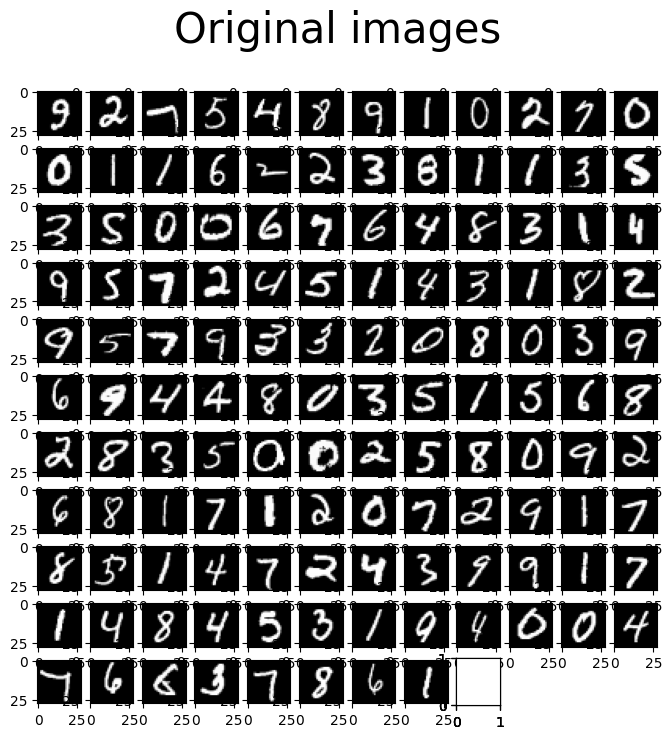

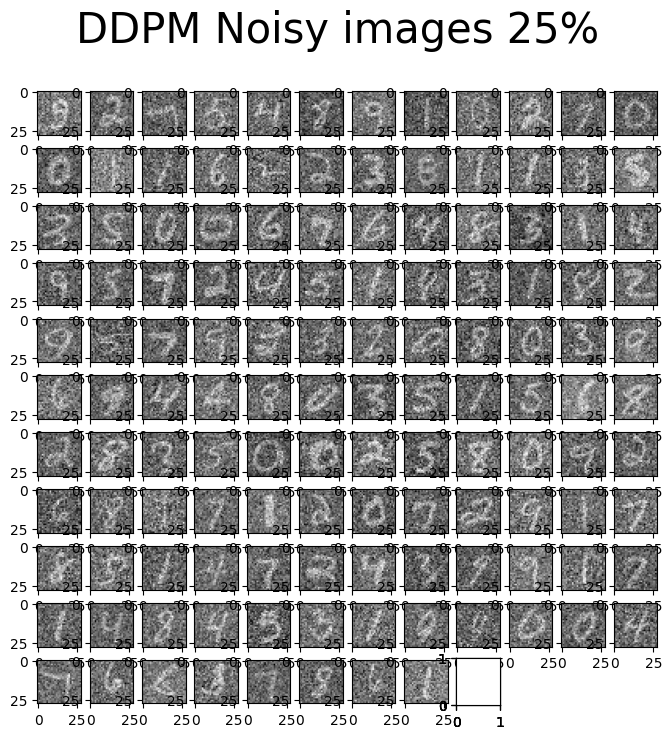

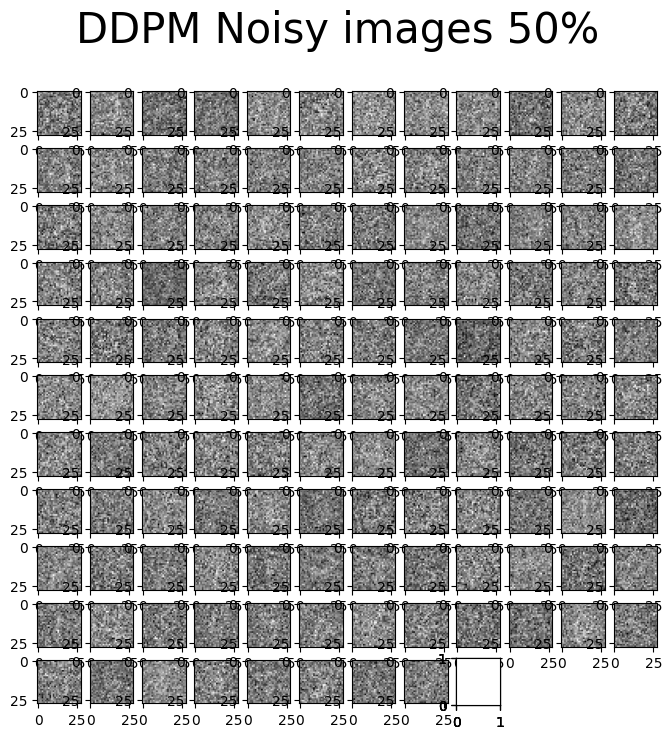

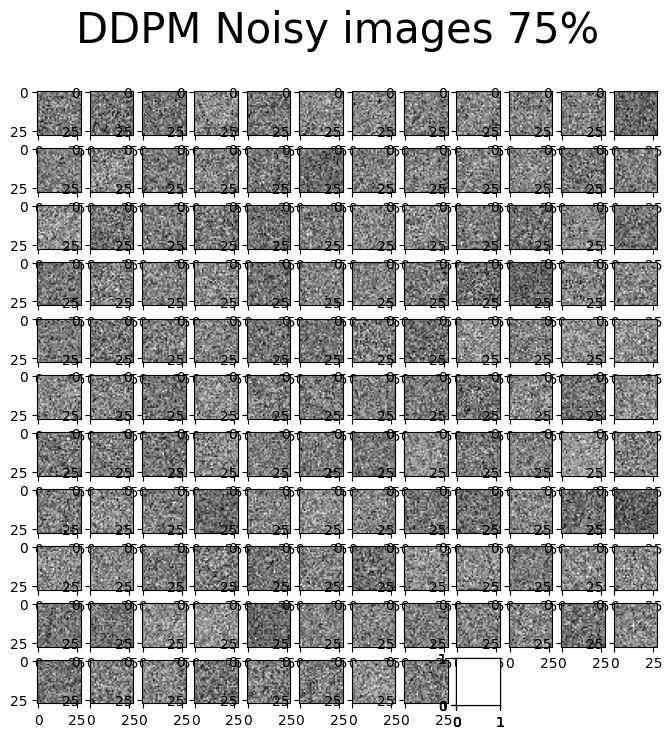

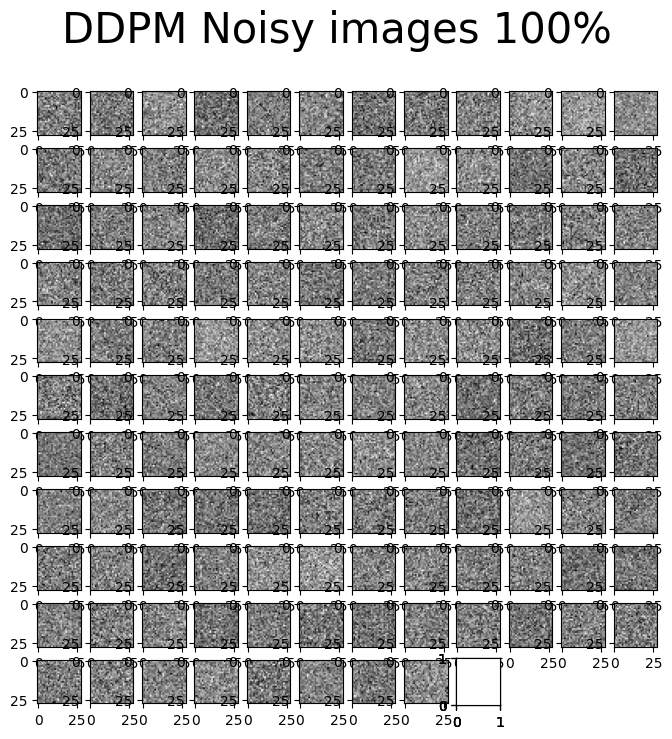

In [180]:
# Optionally, show the diffusion (forward) process
show_forward(ddpm, loader, device)

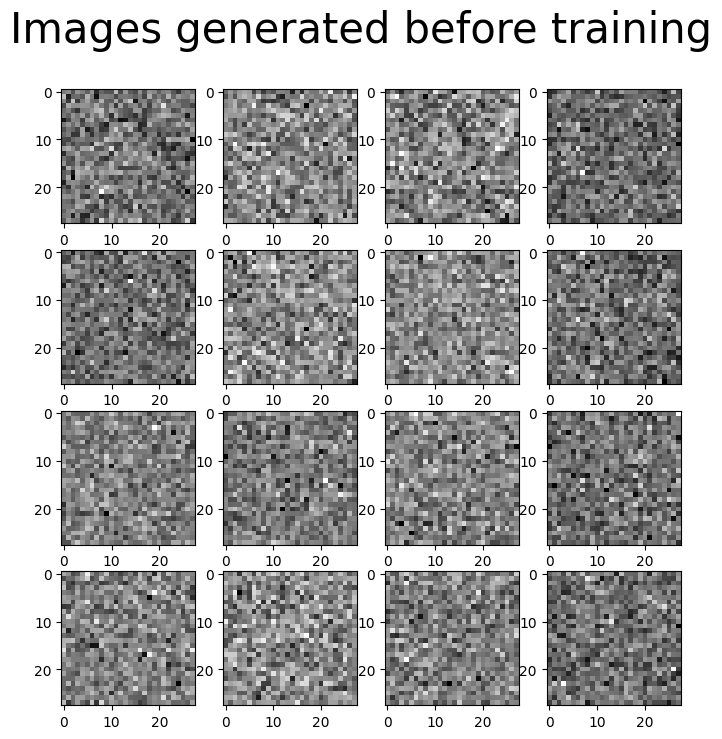

In [181]:
# Optionally, show the denoising (backward) process
generated = generate_new_images(ddpm, gif_name="before_training.gif")
show_images(generated, "Images generated before training")

# Training loop

The training loop is fairly simple. With each batch of our dataset, we run the forward process on the batch. We use a different timesteps $t$ for each of the `N` images in our `(N, C, H, W)` batch tensor to guarantee more training stability. The added noise is a `(N, C, H, W)` tensor $\epsilon$.

Once we obtained the noisy images, we try to predict $\epsilon$ out of them with our network. We optimize with a simple Mean-Squared Error (MSE) loss.

Complete the code bellow: 1., 2., 3., 4..

In [184]:
def training_loop(ddpm, loader, n_epochs, optim, device, display=False, store_path="ddpm_model.pt"):
    mse = nn.MSELoss()
    best_loss = float("inf")
    n_steps = ddpm.n_steps

    for epoch in tqdm(range(n_epochs), desc=f"Training progress", colour="#00ff00"):
        epoch_loss = 0.0
        for step, batch in enumerate(tqdm(loader, leave=False, desc=f"Epoch {epoch + 1}/{n_epochs}", colour="#005500")):
            # Loading data
            x0 = batch[0].to(device)
            n = len(x0)

            # Picking some noise for each of the images in the batch, a timestep and the respective alpha_bars
            eta = torch.randn_like(x0).to(device)
            t = torch.randint(0, n_steps, (n,)).to(device)

            #1. Computing the noisy image based on x0 and the time-step (forward process)
            noisy_imgs = ddpm.forward(x0, t, eta)
            # noisy_imgs - noisy images based on the original images and the noise added to them
            # eta - noise added to the original images

            #2. Getting model estimation of noise based on the images and the time-step
            eta_theta = ddpm.backward(noisy_imgs, t)
            # eta_theta - mean of the noise predicted by the model
            
            #3. Optimizing the MSE between the noise plugged and the predicted noise
            loss = mse(eta_theta, eta)
            # loss - mean squared error between the noise added to the original images and the noise predicted by the model
            
            #4. optimizer step
            optim.zero_grad()
            loss.backward()
            optim.step()

            epoch_loss += loss.item() * len(x0) / len(loader.dataset)

        # Display images generated at this epoch
        if display:
            show_images(generate_new_images(ddpm, device=device), f"Images generated at epoch {epoch + 1}")

        log_string = f"Loss at epoch {epoch + 1}: {epoch_loss:.3f}"

        # Storing the model
        if best_loss > epoch_loss:
            best_loss = epoch_loss
            torch.save(ddpm.state_dict(), store_path)
            log_string += " --> Best model ever (stored)"

        print(log_string)

In [ ]:
# Training
store_path = "ddpm_fashion.pt" if fashion else "ddpm_mnist.pt"
if not no_train:
    training_loop(ddpm, loader, n_epochs, optim=Adam(ddpm.parameters(), lr), device=device, store_path=store_path)

Training progress:   0%|          | 0/10 [00:00<?, ?it/s]

# Testing the trained model

Time to check how well our model does. We re-store the best performing model according to our training loss and set it to evaluation mode. Finally, we display a batch of generated images and the relative obtained and nice GIF.

In [ ]:
# Loading the trained model
best_model = MyDDPM(MyUNet(), n_steps=n_steps, device=device)
best_model.load_state_dict(torch.load(store_path, map_location=device))
best_model.eval()
print("Model loaded")

In [ ]:
print("Generating new images")
generated = generate_new_images(
        best_model,
        option = 1,
        n_samples=48,# change the number of samples as needed
        device=device,
        gif_name="fashion.gif" if fashion else "mnist.gif"
    )
show_images(generated, "Final Option 1 result")

In [ ]:
print("Generating new images")
generated = generate_new_images(
        best_model,
        option =2,
        n_samples=48,
        device=device,
        gif_name="fashion.gif" if fashion else "mnist.gif"
    )
show_images(generated, "Final Option 2 result")

# Visualizing the diffusion

In [ ]:
from IPython.display import Image

Image(open('fashion.gif' if fashion else 'mnist.gif','rb').read())

# Adapted from and credits to:


*   MaximeVandegar (Papers in 100 Lines of Code)
*   Kemal Erdem https://medium.com/@kemalpiro/step-by-step-visual-introduction-to-diffusion-models-235942d2f15c
*   Brian Pulfer https://github.com/BrianPulfer


## Papers
- **Denoising Diffusion Implicit Models** by Song et. al. (https://arxiv.org/abs/2010.02502);
- **Improved Denoising Diffusion Probabilistic Models** by Nichol et. al. (https://arxiv.org/abs/2102.09672);
- **Hierarchical Text-Conditional Image Generation with CLIP Latents** by Ramesh et. al. (https://arxiv.org/abs/2204.06125);
- **Photorealistic Text-to-Image Diffusion Models with Deep Language Understanding** by Saharia et. al. (https://arxiv.org/abs/2205.11487);

